# Sentiment Analysis: Full Script
Complete sentiment analysis pipeline with classical ML and deep learning models

## 1. Configuration

In [1]:
# ============================================================================
# DEFAULT CONFIGURATION (used by library if no config provided)
# ============================================================================

DEFAULT_CONFIG = {
    'DATA_PATH': "IMDB Dataset.csv",
    'OUTPUT_DIR': "./sentiment_deep_models_output",
    'CLASSICAL_MODELS_DIR': "./sentiment_student1_output",
    'MAX_FEATURES': 20000,  # Vocabulary size
    'MAX_LEN': 200,         # Maximum sequence length
    'EMBEDDING_DIM': 128,   # Embedding dimension
    'BATCH_SIZE': 64,
    'EPOCHS': 10,
    'VALIDATION_SPLIT': 0.2,
    'RANDOM_STATE': 42
}

# ============================================================================
# CONFIGURATION PRESETS
# ============================================================================

# Quick testing configuration (fast training)
QUICK_TEST_CONFIG = {
    'DATA_PATH': "IMDB Dataset.csv",
    'OUTPUT_DIR': "./sentiment_deep_models_output",
    'CLASSICAL_MODELS_DIR': "./sentiment_student1_output",
    'MAX_FEATURES': 5000,   # Small vocabulary for speed
    'MAX_LEN': 50,          # Short sequences
    'EMBEDDING_DIM': 32,    # Small embeddings
    'BATCH_SIZE': 128,
    'EPOCHS': 5,            # Very few epochs
    'VALIDATION_SPLIT': 0.2,
    'RANDOM_STATE': 42,
    'USE_GLOVE': False,     # Disable GloVe for quick testing
    'GLOVE_PATH': None
}

# Standard configuration (balanced performance/speed)
STANDARD_CONFIG = {
    'DATA_PATH': "IMDB Dataset.csv",
    'OUTPUT_DIR': "./sentiment_deep_models_output", 
    'CLASSICAL_MODELS_DIR': "./sentiment_student1_output",
    'MAX_FEATURES': 20000,
    'MAX_LEN': 200,
    'EMBEDDING_DIM': 128,
    'BATCH_SIZE': 64,
    'EPOCHS': 10,
    'VALIDATION_SPLIT': 0.2,
    'RANDOM_STATE': 42,
    'USE_GLOVE': False,     
    'GLOVE_PATH': None
}

# High performance configuration (longer training, better results)
HIGH_PERFORMANCE_CONFIG = {
    'DATA_PATH': "IMDB Dataset.csv",
    'OUTPUT_DIR': "./sentiment_deep_models_output",
    'CLASSICAL_MODELS_DIR': "./sentiment_student1_output", 
    'MAX_FEATURES': 50000,  # Large vocabulary
    'MAX_LEN': 400,         # Long sequences
    'EMBEDDING_DIM': 256,   # Large embeddings
    'BATCH_SIZE': 32,       # Smaller batches for stability
    'EPOCHS': 20,           # More training
    'VALIDATION_SPLIT': 0.2,
    'RANDOM_STATE': 42,
    'USE_GLOVE': False,
    'GLOVE_PATH': None
}

# Transformer-optimized configuration
TRANSFORMER_CONFIG = {
    'DATA_PATH': "IMDB Dataset.csv",
    'OUTPUT_DIR': "./sentiment_deep_models_output",
    'CLASSICAL_MODELS_DIR': "./sentiment_student1_output",
    'MAX_FEATURES': 30000,
    'MAX_LEN': 256,         # Good for attention mechanisms
    'EMBEDDING_DIM': 100,   # Should be divisible by number of attention heads
    'BATCH_SIZE': 32,       # Smaller for transformer memory requirements
    'EPOCHS': 15,
    'VALIDATION_SPLIT': 0.2,
    'RANDOM_STATE': 42,
    'USE_GLOVE': False,
    'GLOVE_PATH': None
}

# Memory-efficient configuration (for limited GPU memory)
CUSTOM_CONFIG = {
    'DATA_PATH': "IMDB Dataset.csv",
    'OUTPUT_DIR': "./sentiment_deep_models_output", 
    'CLASSICAL_MODELS_DIR': "./sentiment_student1_output",
    'MAX_FEATURES': 10000,
    'MAX_LEN': 200,
    'EMBEDDING_DIM': 256,
    'BATCH_SIZE': 32,
    'EPOCHS': 10,
    'VALIDATION_SPLIT': 0.2,
    'RANDOM_STATE': 42
}

## 2. Text Preprocessing Functions

In [2]:
import re
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def clean_text(text):
    """Lightweight cleaning: remove HTML, lowercase, remove urls, punctuation, digits, collapse spaces."""
    if not isinstance(text, str):
        return ""
    text = re.sub(r"<.*?>", " ", text)                      # remove html tags
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)    # remove urls
    # replace punctuation with spaces
    text = text.translate(str.maketrans(string.punctuation, " " * len(string.punctuation)))
    text = re.sub(r"\d+", " ", text)                        # remove digits
    text = re.sub(r"\s+", " ", text).strip()
    return text

def remove_stopwords_and_short(tokens):
    """Remove stop words and short tokens"""
    stopwords = ENGLISH_STOP_WORDS
    return [t for t in tokens if t not in stopwords and len(t) > 1]

def remove_stopwords_and_short_keep_negation(tokens):
    """Keep important negation words because they matter for sentiment"""
    stopwords = ENGLISH_STOP_WORDS - {'no', 'nor', 'not', 'never'}
    return [t for t in tokens if t not in stopwords and len(t) > 1]

def preprocess_series(series, keep_negation=False):
    """
    Preprocess a pandas Series of text data
    
    Steps:
    1. Clean text (remove HTML, punctuation, etc.)
    2. Tokenize (split into words)
    3. Remove stop words and short words
    4. Join back into string
    """
    cleaned = series.fillna("").map(clean_text)
    tokenized = cleaned.map(lambda s: s.split())
    
    if keep_negation:
        filtered = tokenized.map(remove_stopwords_and_short_keep_negation)
    else:
        filtered = tokenized.map(remove_stopwords_and_short)
    
    return filtered.map(lambda tokens: " ".join(tokens))

def preprocess_single_text(text, keep_negation=False):
    """
    Preprocess a single text string
    """
    if not isinstance(text, str):
        return ""
    
    cleaned = clean_text(text)
    tokens = cleaned.split()
    
    if keep_negation:
        filtered_tokens = remove_stopwords_and_short_keep_negation(tokens)
    else:
        filtered_tokens = remove_stopwords_and_short(tokens)
    
    return " ".join(filtered_tokens)

def get_preprocessing_stats(original_series, processed_series):
    """
    Get statistics about the preprocessing results
    """
    stats = {
        'original_avg_length': original_series.str.len().mean(),
        'processed_avg_length': processed_series.str.len().mean(),
        'original_word_count': original_series.str.split().str.len().mean(),
        'processed_word_count': processed_series.str.split().str.len().mean(),
        'reduction_ratio': 1 - (processed_series.str.len().mean() / original_series.str.len().mean())
    }
    return stats

## 3. Classical ML: Imports and Setup

In [3]:
import os
import pickle
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn import metrics

# Configuration
DATA_PATH = "IMDB Dataset.csv"
OUTPUT_DIR = "./sentiment_student1_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)
RANDOM_STATE = 42

def load_data(path=DATA_PATH):
    df = pd.read_csv(path)
    if 'review' not in df.columns or 'sentiment' not in df.columns:
        raise ValueError("Expected columns 'review' and 'sentiment' in CSV.")
    return df

## 4. Classical ML: Load, Preprocess, and EDA

Loading dataset...
Dataset shape: (50000, 2)

Preprocessing text (cleaning, stopwords removal)...

Class counts:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64


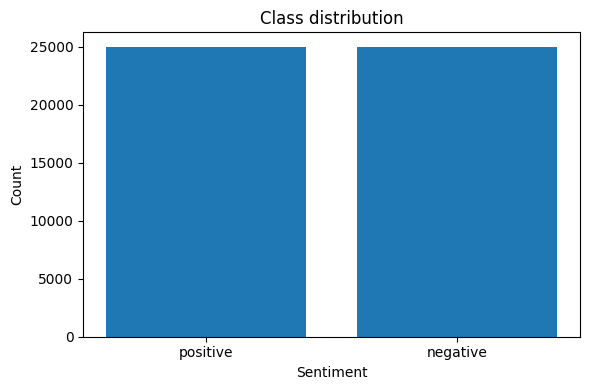

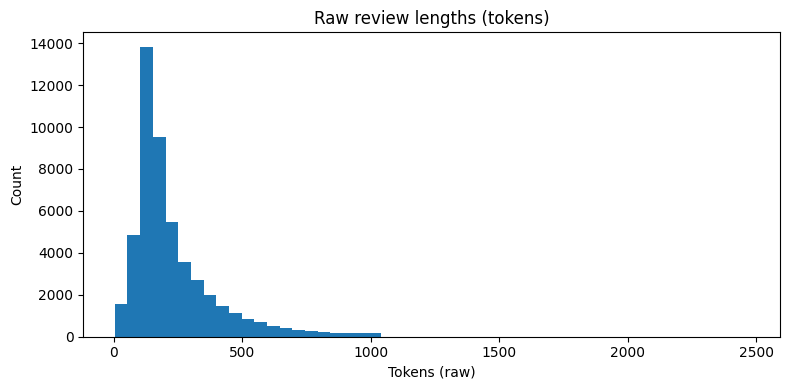

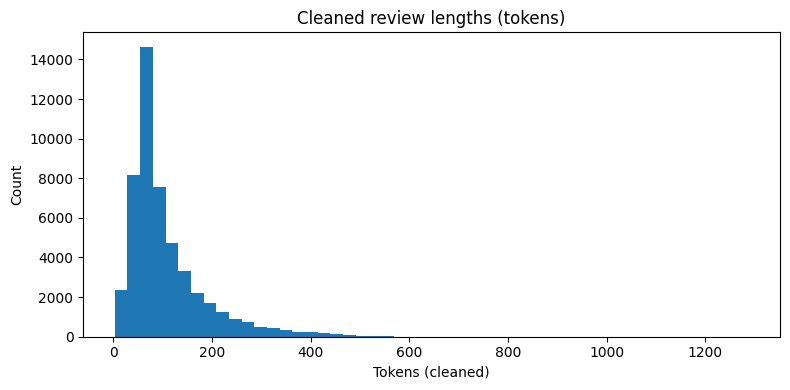


Average cleaned review length by class:
 sentiment
negative    106.47796
positive    109.21996
Name: review_len_clean, dtype: float64

Top positive words: [('film', 42108), ('movie', 37853), ('not', 28303), ('like', 17714), ('good', 15025)]

Top negative words: [('movie', 50118), ('film', 37597), ('not', 32447), ('like', 22458), ('just', 21074)]


In [4]:
print("Loading dataset...")
df = load_data(DATA_PATH)
print("Dataset shape:", df.shape)

print("\nPreprocessing text (cleaning, stopwords removal)...")
df['clean_review'] = preprocess_series(df['review'], keep_negation=True)
df['review_len_raw'] = df['review'].fillna("").map(lambda s: len(s.split()))
df['review_len_clean'] = df['clean_review'].map(lambda s: len(s.split()))

# Save small sample for inspection
df.sample(200, random_state=RANDOM_STATE).to_csv(os.path.join(OUTPUT_DIR, "cleaned_sample.csv"), index=False)

# Class distribution
class_counts = df['sentiment'].value_counts()
print("\nClass counts:\n", class_counts)

plt.figure(figsize=(6,4))
plt.bar(class_counts.index, class_counts.values)
plt.title("Class distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_distribution.png"))
plt.show()

# Length histograms
plt.figure(figsize=(8,4))
plt.hist(df['review_len_raw'], bins=50)
plt.title("Raw review lengths (tokens)")
plt.xlabel("Tokens (raw)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "hist_len_raw.png"))
plt.show()

plt.figure(figsize=(8,4))
plt.hist(df['review_len_clean'], bins=50)
plt.title("Cleaned review lengths (tokens)")
plt.xlabel("Tokens (cleaned)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "hist_len_clean.png"))
plt.show()

# Average cleaned review length by class
avg_len_by_class = df.groupby('sentiment')['review_len_clean'].mean()
print("\nAverage cleaned review length by class:\n", avg_len_by_class)
avg_len_by_class.to_csv(os.path.join(OUTPUT_DIR, "avg_review_len_by_class.csv"), header=['avg_review_len_clean'])

# Top words per class
def top_n_words_for_class(df, label, n=25, max_features=5000):
    vect = CountVectorizer(max_features=max_features)
    texts = df[df['sentiment'] == label]['clean_review']
    X = vect.fit_transform(texts)
    sums = np.array(X.sum(axis=0)).ravel()
    idx = np.argsort(sums)[::-1][:n]
    features = np.array(vect.get_feature_names_out())[idx]
    counts = sums[idx]
    return list(zip(features, counts))

# Top bigrams per class
def top_n_bigrams_for_class(df, label, n=20, max_features=5000):
    vect = CountVectorizer(max_features=max_features, ngram_range=(2, 2))
    texts = df[df['sentiment'] == label]['clean_review']
    X = vect.fit_transform(texts)
    sums = np.array(X.sum(axis=0)).ravel()
    idx = np.argsort(sums)[::-1][:n]
    features = np.array(vect.get_feature_names_out())[idx]
    counts = sums[idx]
    return list(zip(features, counts))

top_pos = top_n_words_for_class(df, 'positive', n=20)
top_neg = top_n_words_for_class(df, 'negative', n=20)
print("\nTop positive words:", top_pos[:5])
print("\nTop negative words:", top_neg[:5])

# Save top words
pd.DataFrame(top_pos, columns=["word", "count"]).to_csv(os.path.join(OUTPUT_DIR, "top_positive_words.csv"), index=False)
pd.DataFrame(top_neg, columns=["word", "count"]).to_csv(os.path.join(OUTPUT_DIR, "top_negative_words.csv"), index=False)

top_pos_bigrams = top_n_bigrams_for_class(df, 'positive', n=20)
top_neg_bigrams = top_n_bigrams_for_class(df, 'negative', n=20)

pd.DataFrame(top_pos_bigrams, columns=["bigram", "count"]).to_csv(os.path.join(OUTPUT_DIR, "top_positive_bigrams.csv"), index=False)
pd.DataFrame(top_neg_bigrams, columns=["bigram", "count"]).to_csv(os.path.join(OUTPUT_DIR, "top_negative_bigrams.csv"), index=False)

## 5. Classical ML: Train and Evaluate Models

In [10]:
# Labels: positive -> 1, negative -> 0
y = df['sentiment'].map({'positive': 1, 'negative': 0}).astype(int)
X = df['clean_review']

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,
                                                    stratify=y, random_state=RANDOM_STATE)
print("\nTrain size:", X_train.shape[0], "Test size:", X_test.shape[0])

# TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2), min_df=2, max_df=0.9, sublinear_tf=True)

# Helper evaluation function
def evaluate(pipeline, X_test, y_test, name):
    preds = pipeline.predict(X_test)
    acc = metrics.accuracy_score(y_test, preds)
    f1 = metrics.f1_score(y_test, preds)
    report = metrics.classification_report(y_test, preds, target_names=['negative','positive'])
    cm = metrics.confusion_matrix(y_test, preds)
    print(f"\n--- {name} ---")
    print("Accuracy:", acc)
    print("F1 score:", f1)
    print(report)
    print("Confusion matrix:\n", cm)

    # ROC AUC if available
    y_score = None
    final_step = list(pipeline.named_steps.keys())[-1]
    clf = pipeline.named_steps[final_step]
    try:
        if hasattr(clf, "predict_proba"):
            y_score = pipeline.predict_proba(X_test)[:,1]
        elif hasattr(clf, "decision_function"):
            y_score = pipeline.decision_function(X_test)
    except Exception:
        y_score = None

    if y_score is not None:
        auc = metrics.roc_auc_score(y_test, y_score)
        print("ROC AUC:", auc)

# Baseline Logistic Regression
pipe_lr = Pipeline([
    ('tfidf', tfidf),
    ('clf', LogisticRegression(max_iter=1000, solver='liblinear', random_state=RANDOM_STATE))
])
print("\nTraining LogisticRegression (baseline)...")
pipe_lr.fit(X_train, y_train)
evaluate(pipe_lr, X_test, y_test, "LogisticRegression_baseline")

# Multinomial Naive Bayes
pipe_nb = Pipeline([('tfidf', tfidf), ('clf', MultinomialNB())])
print("\nTraining MultinomialNB...")
pipe_nb.fit(X_train, y_train)
evaluate(pipe_nb, X_test, y_test, "MultinomialNB")

# Linear SVM
pipe_svc = Pipeline([('tfidf', tfidf), ('clf', LinearSVC(max_iter=2000, random_state=RANDOM_STATE))])
print("\nTraining LinearSVC...")
pipe_svc.fit(X_train, y_train)
evaluate(pipe_svc, X_test, y_test, "LinearSVC")

# SGDClassifier
pipe_sgd = Pipeline([
    ('tfidf', tfidf),
    ('clf', SGDClassifier(loss='hinge', max_iter=2000, random_state=RANDOM_STATE))
])
print("\nTraining SGDClassifier...")
pipe_sgd.fit(X_train, y_train)
evaluate(pipe_sgd, X_test, y_test, "SGDClassifier")

print("\nClassical models training complete!")


Train size: 40000 Test size: 10000

Training LogisticRegression (baseline)...

--- LogisticRegression_baseline ---
Accuracy: 0.9052
F1 score: 0.9060083283759667
              precision    recall  f1-score   support

    negative       0.91      0.90      0.90      5000
    positive       0.90      0.91      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000

Confusion matrix:
 [[4483  517]
 [ 431 4569]]
ROC AUC: 0.9659524

Training MultinomialNB...

--- MultinomialNB ---
Accuracy: 0.8744
F1 score: 0.8763292634895629
              precision    recall  f1-score   support

    negative       0.89      0.86      0.87      5000
    positive       0.86      0.89      0.88      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000

Confusion matrix:
 [[42

## 6. Deep Learning: Imports and Setup

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Embedding, LSTM, GRU, SimpleRNN, Dropout, 
    GlobalMaxPooling1D, GlobalAveragePooling1D, Bidirectional,
    MultiHeadAttention, LayerNormalization, Input, Add, Layer
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
import json
from datetime import datetime
import io
import sys

## 7. Deep Learning Sentiment Analyzer Class

In [7]:
class DeepSentimentAnalyzer:
    """Deep Learning Sentiment Analyzer with multiple architectures"""
    
    def __init__(self, config=None, experiment_name="default"):
        self.config = config if config is not None else DEFAULT_CONFIG.copy()
        self.experiment_name = experiment_name
        base_output_dir = self.config['OUTPUT_DIR']
        self.output_dir = os.path.join(base_output_dir, experiment_name)
        os.makedirs(self.output_dir, exist_ok=True)
        
        self.max_features = self.config['MAX_FEATURES']
        self.max_len = self.config['MAX_LEN']
        self.embedding_dim = self.config['EMBEDDING_DIM']
        self.tokenizer = None
        self.models = {}
        self.histories = {}
        self.use_glove = self.config.get('USE_GLOVE', False)
        self.glove_path = self.config.get('GLOVE_PATH', None)
        self.embedding_matrix = None
        
        np.random.seed(self.config['RANDOM_STATE'])
        tf.random.set_seed(self.config['RANDOM_STATE'])
    
    def load_and_preprocess_data(self):
        """Load and preprocess data"""
        print("Loading dataset...")
        df = pd.read_csv(self.config['DATA_PATH'])
        
        print("Preprocessing text...")
        df['clean_review'] = preprocess_series(df['review'], keep_negation=True)
        
        y = df['sentiment'].map({'positive': 1, 'negative': 0}).values
        texts = df['clean_review'].values
        
        X_train, X_test, y_train, y_test = train_test_split(
            texts, y, test_size=0.2, random_state=self.config['RANDOM_STATE'], stratify=y
        )
        
        print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")
        
        print("Tokenizing texts...")
        self.tokenizer = Tokenizer(num_words=self.max_features, oov_token="<OOV>")
        self.tokenizer.fit_on_texts(X_train)
        
        X_train_seq = self.tokenizer.texts_to_sequences(X_train)
        X_test_seq = self.tokenizer.texts_to_sequences(X_test)
        
        X_train_pad = pad_sequences(X_train_seq, maxlen=self.max_len)
        X_test_pad = pad_sequences(X_test_seq, maxlen=self.max_len)
        
        print(f"Vocabulary size: {len(self.tokenizer.word_index)}")
        print(f"Sequence shape: {X_train_pad.shape}")
        
        self.X_train, self.X_test = X_train_pad, X_test_pad
        self.y_train, self.y_test = y_train, y_test
        self.raw_texts_train, self.raw_texts_test = X_train, X_test
        
        return X_train_pad, X_test_pad, y_train, y_test
    
    def build_simple_rnn(self):
        """Build Simple RNN model"""
        model = Sequential([
            Embedding(self.max_features, self.embedding_dim, input_length=self.max_len),
            SimpleRNN(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
            GlobalMaxPooling1D(),
            Dense(64, activation='relu'),
            Dropout(0.3),
            Dense(32, activation='relu'),
            Dropout(0.3),
            Dense(1, activation='sigmoid')
        ])
        model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
        return model
    
    def build_lstm(self, bidirectional=False):
        """Build LSTM model"""
        model = Sequential()
        model.add(Embedding(self.max_features, self.embedding_dim, input_length=self.max_len))
        if bidirectional:
            model.add(Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3)))
        else:
            model.add(LSTM(64, dropout=0.3, recurrent_dropout=0.3))
        model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.01)))
        model.add(Dropout(0.5))
        model.add(Dense(1, activation='sigmoid'))
        model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
        return model
    
    def build_gru(self, bidirectional=False):
        """Build GRU model"""
        model = Sequential()
        model.add(Embedding(self.max_features, self.embedding_dim, input_length=self.max_len))
        if bidirectional:
            model.add(Bidirectional(GRU(64, dropout=0.3, recurrent_dropout=0.3)))
        else:
            model.add(GRU(64, dropout=0.3, recurrent_dropout=0.3))
        model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.01)))
        model.add(Dropout(0.5))
        model.add(Dense(1, activation='sigmoid'))
        model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
        return model
    
    def build_transformer_encoder(self):
        """Build Transformer encoder model"""
        inputs = Input(shape=(self.max_len,))
        embedding_layer = Embedding(self.max_features, self.embedding_dim)(inputs)
        
        attention_output = MultiHeadAttention(
            num_heads=4, key_dim=self.embedding_dim//4, dropout=0.1
        )(embedding_layer, embedding_layer)
        
        attention_output = LayerNormalization()(Add()([embedding_layer, attention_output]))
        
        ff_output = Dense(64, activation='relu')(attention_output)
        ff_output = Dropout(0.2)(ff_output)
        ff_output = Dense(self.embedding_dim)(ff_output)
        
        transformer_output = LayerNormalization()(Add()([attention_output, ff_output]))
        
        pooled = GlobalAveragePooling1D()(transformer_output)
        dropout = Dropout(0.3)(pooled)
        dense = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(dropout)
        dropout2 = Dropout(0.5)(dense)
        outputs = Dense(1, activation='sigmoid')(dropout2)
        
        model = Model(inputs=inputs, outputs=outputs)
        model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
        return model
    
    def train_model(self, model, model_name, X_train, y_train):
        """Train a model with callbacks"""
        print(f"\nTraining {model_name}...")
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-6),
            ModelCheckpoint(
                os.path.join(self.output_dir, f'{model_name}_best.h5'),
                monitor='val_accuracy', save_best_only=True, mode='max'
            )
        ]
        
        history = model.fit(
            X_train, y_train, batch_size=self.config['BATCH_SIZE'],
            epochs=self.config['EPOCHS'], validation_split=self.config['VALIDATION_SPLIT'],
            callbacks=callbacks, verbose=1
        )
        
        self.models[model_name] = model
        self.histories[model_name] = history
        return model, history
    
    def evaluate_model(self, model, model_name, X_test, y_test):
        """Comprehensive model evaluation"""
        print(f"\n=== Evaluating {model_name} ===")
        
        y_pred_proba = model.predict(X_test, verbose=0)
        y_pred = (y_pred_proba > 0.5).astype(int)
        
        accuracy = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred_proba)
        
        print(f"Accuracy: {accuracy:.4f}")
        print(f"ROC AUC: {auc:.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))
        
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Negative', 'Positive'],
                   yticklabels=['Negative', 'Positive'])
        plt.title(f'Confusion Matrix - {model_name}')
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, f'confusion_matrix_{model_name}.png'))
        plt.close()
        
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})')
        plt.plot([0, 1], [0, 1], 'k--', label='Random')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {model_name}')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, f'roc_curve_{model_name}.png'))
        plt.close()
        
        return {
            'model_name': model_name,
            'accuracy': accuracy,
            'auc': auc,
            'predictions': y_pred_proba.flatten(),
            'true_labels': y_test
        }
    
    def plot_training_history(self, model_name):
        """Plot training history"""
        if model_name not in self.histories:
            return
        
        history = self.histories[model_name]
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        axes[0].plot(history.history['accuracy'], label='Training Accuracy')
        axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
        axes[0].set_title(f'{model_name} - Accuracy')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Accuracy')
        axes[0].legend()
        axes[0].grid(True)
        
        axes[1].plot(history.history['loss'], label='Training Loss')
        axes[1].plot(history.history['val_loss'], label='Validation Loss')
        axes[1].set_title(f'{model_name} - Loss')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].legend()
        axes[1].grid(True)
        
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, f'training_history_{model_name}.png'))
        plt.close()
    
    def run_complete_analysis(self):
        """Run complete deep learning analysis"""
        print("=" * 60)
        print("DEEP LEARNING SENTIMENT ANALYSIS")
        print("=" * 60)
        
        X_train, X_test, y_train, y_test = self.load_and_preprocess_data()
        
        model_configs = [
            ('SimpleRNN', self.build_simple_rnn),
            ('LSTM', lambda: self.build_lstm(bidirectional=False)),
            ('BiLSTM', lambda: self.build_lstm(bidirectional=True)),
            ('GRU', lambda: self.build_gru(bidirectional=False)),
            ('BiGRU', lambda: self.build_gru(bidirectional=True)),
            ('Transformer', self.build_transformer_encoder)
        ]
        
        results = []
        for model_name, model_builder in model_configs:
            print(f"\n{'-'*40}")
            print(f"Processing {model_name}")
            print(f"{'-'*40}")
            
            model = model_builder()
            print(f"Model {model_name} architecture:")
            model.summary()
            
            trained_model, history = self.train_model(model, model_name, X_train, y_train)
            self.plot_training_history(model_name)
            result = self.evaluate_model(trained_model, model_name, X_test, y_test)
            results.append(result)
            
            model.save(os.path.join(self.output_dir, f'{model_name}_model.h5'))
            print(f"Model {model_name} saved successfully!")
        
        return results

## 8. Run Full Deep Learning Analysis

In [12]:
# Train all deep learning models with standard configuration
analyzer = DeepSentimentAnalyzer(config=DEFAULT_CONFIG, experiment_name='deep_standard')
results = analyzer.run_complete_analysis()

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)
print(f"Results saved in: {analyzer.output_dir}")

DEEP LEARNING SENTIMENT ANALYSIS
Loading dataset...
Preprocessing text...
Train samples: 40000, Test samples: 10000
Tokenizing texts...
Vocabulary size: 91337
Sequence shape: (40000, 200)

----------------------------------------
Processing SimpleRNN
----------------------------------------
Model SimpleRNN architecture:


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...


Training SimpleRNN...
Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.4997 - loss: 0.7053

500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 80ms/step - accuracy: 0.4987 - loss: 0.6975 - val_accuracy: 0.4989 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5123 - loss: 0.6931

500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 84ms/step - accuracy: 0.5172 - loss: 0.6924 - val_accuracy: 0.6511 - val_loss: 0.6748 - learning_rate: 0.0010
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.6857 - loss: 0.5885

500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 81ms/step - accuracy: 0.7490 - loss: 0.5205 - val_accuracy: 0.8098 - val_loss: 0.4149 - learning_rate: 0.0010
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 88ms/step - accuracy: 0.8180 - loss: 0.4153 - val_accuracy: 0.7581 - val_loss: 0.4888 - learning_rate: 0.0010
Epoch 5/10
116/500 ━━━━━━━━━━━━━━━━━━━━ 39s 103ms/step - accuracy: 0.7832 - loss: 0.4790

KeyboardInterrupt: 